Loaded 52696 rows. Sequence length 90, prediction days 7.
Train sequences: 42080, Test sequences: 10520


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_1 (SimpleRNN)        │ (None, 50)             │         2,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           357 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,957 (11.55 KB)

 Trainable params: 2,957 (11.55 KB)

 Non-trainable params: 0 (0.00 B)

Training the model...
Epoch 1/50
1184/1184 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - loss: 0.0118 - val_loss: 2.8860e-04
Epoch 2/50
1184/1184 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - loss: 4.3025e-04 - val_loss: 2.7053e-04
Epoch 3/50
1184/1184 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - loss: 3.7938e-04 - val_loss: 2.1244e-04
Epoch 4/50
1184/1184 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - loss: 3.6934e-04 - val_loss: 2.1478e-04
Epoch 5/50
1184/1184 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - loss: 3.4796e-04 - val_loss: 2.0292e-04
Epoch 6/50
1184/1184 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - loss: 3.3364e-04 - val_loss: 2.0481e-04
Epoch 7/50
1184/1184 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - loss: 3.3467e-04 - val_loss: 1.8857e-04
Epoch 8/50
1184/1184 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - loss: 3.2434e-04 - val_loss: 1.8819e-04
Epoch 9/50
1184/1184 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - loss: 3.1739e-04 - val_loss: 1.9049e-04
Epoch 10/50
1184/1184 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - loss: 2.9434e-04 - val_loss: 1.6908e-04
Epoch 11/50
1184/118

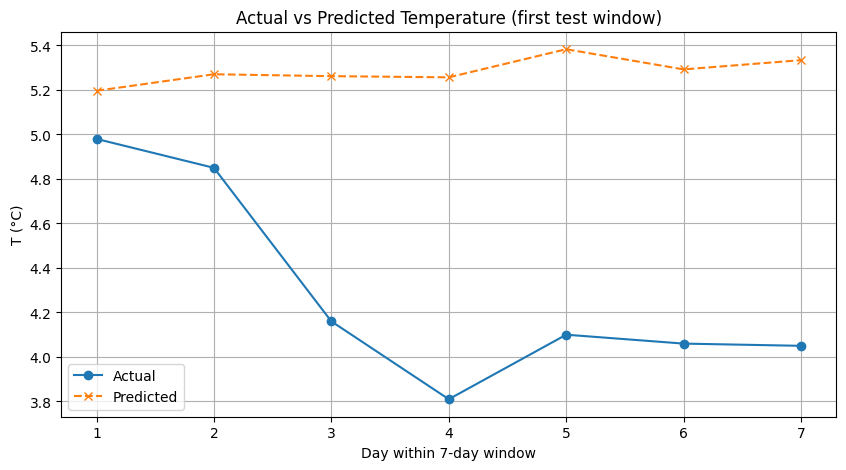

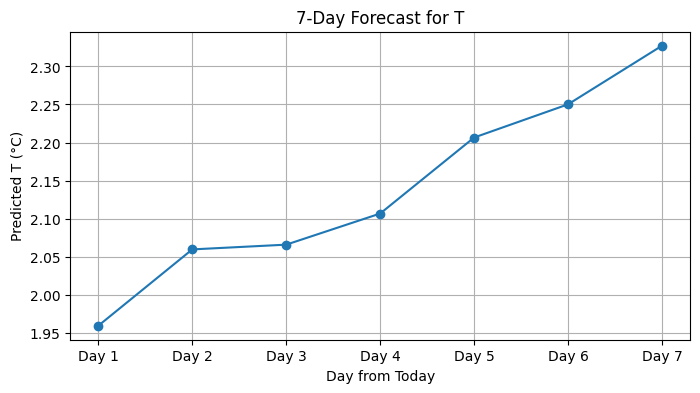

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense
from tensorflow.keras.callbacks import EarlyStopping

# ---- Colab helper: upload file if not present ----
CSV_FILE_PATH = 'cleaned_weather.csv'  # change if you have the file elsewhere

if not os.path.exists(CSV_FILE_PATH):
    try:
        from google.colab import files
        print("cleaned_weather.csv not found in working dir. Please upload the CSV file now.")
        uploaded = files.upload()  # prompts file upload in Colab
        # Move the uploaded file to CSV_FILE_PATH if name differs
        for fn in uploaded:
            if fn != CSV_FILE_PATH:
                os.rename(fn, CSV_FILE_PATH)
        print("Upload complete.")
    except Exception as e:
        print("Could not use google.colab.files.upload() — running outside Colab or import failed.")
        raise

# ---- Configuration ----
TARGET_COLUMN = 'T'         # column to predict (air temperature)
SEQUENCE_LENGTH = 90        # lookback days
PREDICTION_DAYS = 7         # predict next 7 days

# ---- 1. Load and Preprocess Data ----
def load_and_preprocess_data(filepath, column_name):
    if not os.path.exists(filepath):
        raise FileNotFoundError(f"{filepath} not found. Upload or set correct path.")
    df = pd.read_csv(filepath)
    if column_name not in df.columns:
        raise ValueError(f"Column '{column_name}' not found in CSV. Available columns: {list(df.columns)}")
    df = df.dropna(subset=[column_name]).reset_index(drop=True)
    data = df[column_name].values.reshape(-1, 1).astype(float)
    scaler = MinMaxScaler(feature_range=(0, 1))
    scaled_data = scaler.fit_transform(data)
    return scaled_data, scaler, df

def create_sequences_for_7_day_pred(data, seq_length, pred_days):
    X, y = [], []
    # data expected shape: (n_samples, 1) or 1D array convertible
    arr = data.reshape(-1)
    for i in range(len(arr) - seq_length - pred_days + 1):
        X.append(arr[i:(i + seq_length)])
        y.append(arr[(i + seq_length):(i + seq_length + pred_days)])
    if len(X) == 0:
        return np.array([]), np.array([])
    return np.array(X), np.array(y)

# Load
scaled_data, scaler, df = load_and_preprocess_data(CSV_FILE_PATH, TARGET_COLUMN)
n_rows = scaled_data.shape[0]
print(f"Loaded {n_rows} rows. Sequence length {SEQUENCE_LENGTH}, prediction days {PREDICTION_DAYS}.")

# Sanity check: enough data
min_needed = SEQUENCE_LENGTH + PREDICTION_DAYS
if n_rows < min_needed + 1:
    raise ValueError(f"Not enough rows ({n_rows}) for the chosen SEQUENCE_LENGTH + PREDICTION_DAYS ({min_needed}).")

# --- Option A: create sequences from full dataset then split (preferred) ---
X_all, y_all = create_sequences_for_7_day_pred(scaled_data, SEQUENCE_LENGTH, PREDICTION_DAYS)
if X_all.size == 0:
    raise ValueError("No sequences created. Check data length and parameters.")

# Split (80% train, 20% test) on sequence count
split_idx = int(len(X_all) * 0.8)
X_train = X_all[:split_idx]
y_train = y_all[:split_idx]
X_test  = X_all[split_idx:]
y_test  = y_all[split_idx:]

# reshape for RNN [samples, timesteps, features]
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test  = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

print(f"Train sequences: {X_train.shape[0]}, Test sequences: {X_test.shape[0]}")

# --- 2. Build the RNN Model ---
model = Sequential([
    SimpleRNN(units=50, activation='relu', input_shape=(SEQUENCE_LENGTH, 1)),
    Dense(units=PREDICTION_DAYS)   # outputs PREDICTION_DAYS values
])
model.compile(optimizer='adam', loss='mean_squared_error')
model.summary()

# --- 3. Train the Model ---
print("Training the model...")
# Optional: early stopping to avoid overfitting (uncomment if desired)
# early_stop = EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True)
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.1,
    verbose=1,
    # callbacks=[early_stop]
)

# --- 4. Evaluate the Result ---
predictions_scaled = model.predict(X_test)  # shape (num_test_samples, PREDICTION_DAYS)

# scaler was fitted on shape (n_samples, 1); we must reshape to apply inverse_transform
# Flatten predictions and targets to column vectors, inverse_transform, then reshape back
pred_flat = predictions_scaled.reshape(-1, 1)
pred_inverse = scaler.inverse_transform(pred_flat).reshape(predictions_scaled.shape)

y_test_flat = y_test.reshape(-1, 1)
y_test_inverse = scaler.inverse_transform(y_test_flat).reshape(y_test.shape)

# compute metrics across all predicted days (flattened)
mse = mean_squared_error(y_test_inverse.flatten(), pred_inverse.flatten())
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test_inverse.flatten(), pred_inverse.flatten())

print("-" * 40)
print("Evaluation Metrics on Test Set (across all predicted days):")
print(f"MSE : {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE : {mae:.4f}")
print("-" * 40)

# --- 5. Predict the next 7 days from the *end* of the original dataset ---
last_seq = scaled_data[-SEQUENCE_LENGTH:].reshape(1, SEQUENCE_LENGTH, 1)
final_pred_scaled = model.predict(last_seq)  # shape (1, PREDICTION_DAYS)
final_pred = scaler.inverse_transform(final_pred_scaled.reshape(-1, 1)).reshape(final_pred_scaled.shape)

print(f"Predicted Air Temperatures (T) for the next {PREDICTION_DAYS} days:")
for i, val in enumerate(final_pred.flatten()):
    print(f"Day {i+1}: {val:.2f}°C")

# --- 6. Visualize Results ---
def visualize_test_results(y_true, y_pred, idx=0, title=None):
    """Plots actual vs predicted values for test sequence index `idx`."""
    if y_true.shape[0] == 0:
        print("No test sequences to visualize.")
        return
    plt.figure(figsize=(10,5))
    days = np.arange(1, y_true.shape[1] + 1)
    plt.plot(days, y_true[idx], marker='o', label='Actual')
    plt.plot(days, y_pred[idx], marker='x', linestyle='--', label='Predicted')
    plt.title(title or 'Actual vs Predicted (one 7-day window)')
    plt.xlabel('Day within 7-day window')
    plt.ylabel(f'{TARGET_COLUMN} (°C)')
    plt.xticks(days)
    plt.grid(True)
    plt.legend()
    plt.show()

def visualize_final_forecast(prediction, title=None):
    plt.figure(figsize=(8,4))
    days = np.arange(1, prediction.shape[1] + 1)
    plt.plot(days, prediction.flatten(), marker='o')
    plt.title(title or '7-day Forecast')
    plt.xlabel('Day from Today')
    plt.ylabel(f'Predicted {TARGET_COLUMN} (°C)')
    plt.xticks(days, [f'Day {d}' for d in days])
    plt.grid(True)
    plt.show()

# show first test window comparison and final forecast
visualize_test_results(y_test_inverse, pred_inverse, idx=0, title='Actual vs Predicted Temperature (first test window)')
visualize_final_forecast(final_pred, title=f'7-Day Forecast for {TARGET_COLUMN}')